In [2]:
import copy, random, csv, re
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
 
device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(SEED)

In [3]:
tfm = transforms.ToTensor()
full_train = datasets.FashionMNIST("./data", train=True,  download=True, transform=tfm)
test_ds    = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)
n_unused = len(full_train) - 6000 - 1000
train_ds, val_ds, _ = random_split(
    full_train, [6000, 1000, n_unused],
    generator=torch.Generator().manual_seed(SEED)
)

def make_loader(ds, shuffle, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(ds, batch_size=128, shuffle=shuffle, generator=g if shuffle else None)

val_loader  = make_loader(val_ds,  False)
test_loader = make_loader(test_ds, False)
print(len(train_ds), len(val_ds), len(test_ds))

print(torch.Generator().manual_seed(SEED))

6000 1000 10000


In [ ]:
def build_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    )

# One set of initial weights, shared by both runs
set_seed(SEED)
init_state = copy.deepcopy(build_model().state_dict())

hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0, reduction="sum")
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

@torch.no_grad()
def evaluate(model, loader):
    """Returns hard-loss CE (mean per sample), accuracy, and all confidences."""
    model.eval()
    tot_loss, correct, n, confs = 0.0, 0, 0, []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        tot_loss += hard_loss(logits, y).item()
        correct  += (logits.argmax(-1) == y).sum().item()
        n += y.size(0)
        confs.append(torch.softmax(logits, dim=-1).max(dim=-1).values.cpu())
    return tot_loss / n, correct / n, torch.cat(confs).numpy()

def train_model(train_criterion, epochs=10):
    model = build_model().to(device)
    model.load_state_dict(init_state)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    train_loader = make_loader(train_ds, True, SEED)   # same shuffle order for both runs

    best_val, best_epoch, best_state = float("inf"), None, None
    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            train_criterion(model(x), y).backward()
            opt.step()

        val_loss, val_acc, _ = evaluate(model, val_loader)   # validation always uses hard CE
        print(f"epoch {ep:2d} | val CE {val_loss:.4f} | val acc {val_acc:.4f}")
        if val_loss < best_val:          # strict '<' keeps the earlier epoch on ties
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)    # restore best checkpoint before testing
    return model, best_epoch

In [ ]:
results, test_confs = {}, {}
for name, crit in [("Hard (ls=0.0)", hard_loss), ("Soft (ls=0.1)", soft_loss)]:
    print(f"\n=== {name} ===")
    model, best_ep = train_model(crit, epochs=10)
    _, test_acc, confs = evaluate(model, test_loader)
    results[name] = dict(epoch=best_ep, acc=test_acc, conf=confs.mean())
    test_confs[name] = confs

print("\n{:<16}{:>16}{:>15}{:>20}".format("Model", "Selected epoch", "Test acc", "Mean test conf"))
for k, v in results.items():
    print("{:<16}{:>16d}{:>15.4f}{:>20.4f}".format(k, v["epoch"], v["acc"], v["conf"]))


=== Hard (ls=0.0) ===
epoch  1 | val CE 0.7551 | val acc 0.7310
epoch  2 | val CE 0.6329 | val acc 0.7820
epoch  3 | val CE 0.5538 | val acc 0.8020
epoch  4 | val CE 0.5343 | val acc 0.8160
epoch  5 | val CE 0.4969 | val acc 0.8350
epoch  6 | val CE 0.5003 | val acc 0.8240
epoch  7 | val CE 0.4784 | val acc 0.8370
epoch  8 | val CE 0.4606 | val acc 0.8470
epoch  9 | val CE 0.4641 | val acc 0.8300
epoch 10 | val CE 0.4764 | val acc 0.8330

=== Soft (ls=0.1) ===
epoch  1 | val CE 0.8085 | val acc 0.7390
epoch  2 | val CE 0.7086 | val acc 0.7870
epoch  3 | val CE 0.6464 | val acc 0.8060
epoch  4 | val CE 0.6200 | val acc 0.8170
epoch  5 | val CE 0.5806 | val acc 0.8360
epoch  6 | val CE 0.5776 | val acc 0.8320
epoch  7 | val CE 0.5686 | val acc 0.8410
epoch  8 | val CE 0.5521 | val acc 0.8510
epoch  9 | val CE 0.5565 | val acc 0.8370
epoch 10 | val CE 0.5553 | val acc 0.8330

Model             Selected epoch       Test acc      Mean test conf
Hard (ls=0.0)                  8         0.82

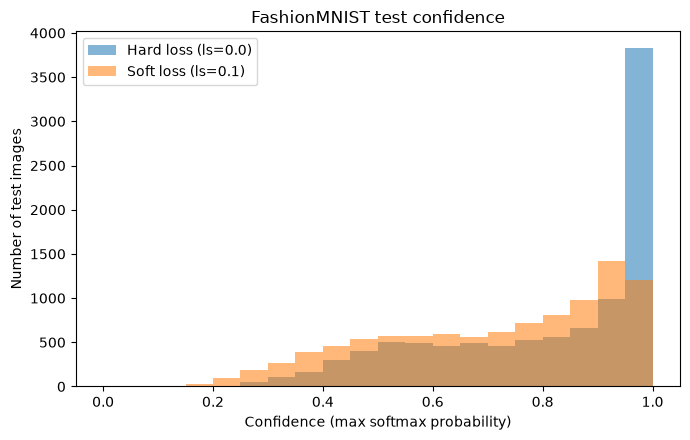

In [ ]:
bins = np.linspace(0, 1, 21)   # 20 equal-width bins from 0 to 1
plt.figure(figsize=(7, 4.5))
plt.hist(test_confs["Hard (ls=0.0)"], bins=bins, alpha=0.55, label="Hard loss (ls=0.0)")
plt.hist(test_confs["Soft (ls=0.1)"], bins=bins, alpha=0.55, label="Soft loss (ls=0.1)")
plt.xlabel("Confidence (max softmax probability)")
plt.ylabel("Number of test images")
plt.title("FashionMNIST test confidence")
plt.legend()
plt.tight_layout()
plt.show()

Label smoothing left accuracy essentially unchanged (82.31% hard vs 82.48% soft, both selected at epoch 8, a 0.17-point gap that is within noise for one seed) but clearly lowered confidence: mean test confidence fell from 0.807 to 0.7145. The histogram shows why: the hard-loss model piles about 3,800 test images into the top bin (0.95 to 1.0), while the soft-loss model has only about 1,200 there and shifts mass into the 0.8 to 0.95 range. With hard targets, cross-entropy keeps falling as the true-class probability approaches 1, so the gradient always pushes the logit gap larger. With a 0.91/0.01 target, the loss is minimized when the model outputs about 0.91 for the true class, and pushing beyond that increases the loss because the 0.01 on the other classes is penalized. That puts a ceiling on useful confidence, so the model has no incentive to produce the extreme logits that dominate the hard-loss histogram

In [ ]:
with open("names.csv", encoding="utf-8-sig", newline="") as f:
    names = sorted({
        re.sub(r"[^a-z]", "", row["Name"].lower())
        for row in csv.DictReader(f)
    } - {""})
assert len(names) == 6478


g = torch.Generator().manual_seed(42)
order = torch.randperm(len(names), generator=g).tolist()
train_names = [names[i] for i in order[:5182]]
val_names   = [names[i] for i in order[5182:5829]]
test_names  = [names[i] for i in order[5829:]]
print(len(train_names), len(val_names), len(test_names))

stoi = {ch: i for i, ch in enumerate("-abcdefghijklmnopqrstuvwxyz")}
itos = {i: ch for ch, i in stoi.items()}   # 0 -> '-' (start/end token)




5182 647 649


In [ ]:
def build_examples(name_list):
    X, Y = [], []
    for name in name_list:
        ctx = [0, 0, 0]                    # reset context for every name
        for ch in name + "-":              # final end token is a target
            ix = stoi[ch]
            X.append(ctx)
            Y.append(ix)
            ctx = ctx[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

Xtr, Ytr = build_examples(train_names)
Xva, Yva = build_examples(val_names)
Xte, Yte = build_examples(test_names)


print(Xtr.shape, Xva.shape, Xte.shape)

torch.Size([38230, 3]) torch.Size([4719, 3]) torch.Size([4703, 3])


In [ ]:
set_seed(43)

embedding = nn.Embedding(27, 2)

network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
)

def forward(context_ids):
    return network(embedding(context_ids).reshape(-1, 6))

criterion = nn.CrossEntropyLoss()   # natural log -> nats per token

@torch.no_grad()
def evaluate(X, Y):
    """Exact mean loss over all predicted tokens (full set in one pass)."""
    embedding.eval(); network.eval()
    return criterion(forward(X), Y).item()

epoch  1 | train 2.8048 | val 2.8023
epoch  2 | train 2.7058 | val 2.7061
epoch  3 | train 2.6395 | val 2.6375
epoch  4 | train 2.5632 | val 2.5602
epoch  5 | train 2.4858 | val 2.4798
epoch  6 | train 2.4351 | val 2.4277
epoch  7 | train 2.4074 | val 2.3999
epoch  8 | train 2.3914 | val 2.3838
epoch  9 | train 2.3807 | val 2.3715
epoch 10 | train 2.3718 | val 2.3641
epoch 11 | train 2.3650 | val 2.3572
epoch 12 | train 2.3587 | val 2.3515
epoch 13 | train 2.3525 | val 2.3460
epoch 14 | train 2.3474 | val 2.3401
epoch 15 | train 2.3436 | val 2.3360
epoch 16 | train 2.3396 | val 2.3327
epoch 17 | train 2.3357 | val 2.3277
epoch 18 | train 2.3323 | val 2.3260
epoch 19 | train 2.3295 | val 2.3226
epoch 20 | train 2.3272 | val 2.3222

Selected epoch: 20
Test loss: 2.3552 nats/token


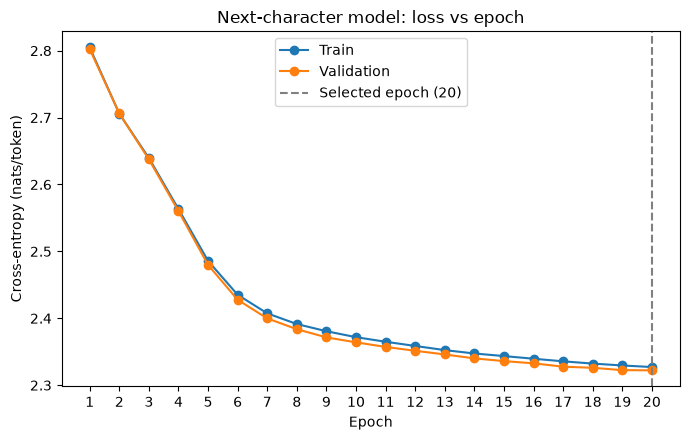

In [ ]:
EPOCHS, BATCH = 20, 256

# both embedding and network parameters go to the optimizer
params = list(embedding.parameters()) + list(network.parameters())
opt = torch.optim.Adam(params, lr=0.001)
shuffle_g = torch.Generator().manual_seed(42)
train_losses, val_losses = [], []
best_val, best_epoch, best_emb, best_net = float("inf"), None, None, None

for ep in range(1, EPOCHS + 1):
    embedding.train(); network.train()
    perm = torch.randperm(len(Xtr), generator=shuffle_g)
    for i in range(0, len(Xtr), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        criterion(forward(Xtr[idx]), Ytr[idx]).backward()
        opt.step()

    # evaluate both sets at the end of the epoch
    tr, va = evaluate(Xtr, Ytr), evaluate(Xva, Yva)
    train_losses.append(tr); val_losses.append(va)
    print(f"epoch {ep:2d} | train {tr:.4f} | val {va:.4f}")

    if va < best_val:                    # strict '<' keeps earlier epoch on ties
        best_val, best_epoch = va, ep
        best_emb = copy.deepcopy(embedding.state_dict())
        best_net = copy.deepcopy(network.state_dict())

# restore best weights (embedding AND network) before testing
embedding.load_state_dict(best_emb)
network.load_state_dict(best_net)

test_loss = evaluate(Xte, Yte)
print(f"\nSelected epoch: {best_epoch}")
print(f"Test loss: {test_loss:.4f} nats/token")

plt.figure(figsize=(7, 4.5))
epochs = range(1, EPOCHS + 1)
plt.plot(epochs, train_losses, marker="o", label="Train")
plt.plot(epochs, val_losses, marker="o", label="Validation")
plt.axvline(float(best_epoch), color="gray", linestyle="--", label=f"Selected epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy (nats/token)")
plt.title("Next-character model: loss vs epoch")
plt.xticks(list(epochs)); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
MAX_LETTERS = 20

@torch.no_grad()
def generate(mode, temperature=1.0):
    embedding.eval(); network.eval()
    ctx, out = [0, 0, 0], []
    for _ in range(MAX_LETTERS):
        logits = forward(torch.tensor([ctx]))
        if mode == "greedy":
            next_id = logits.argmax(dim=-1).item()
        else:
            probabilities = torch.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1).item()
        if next_id == 0:                 # end token
            hit_limit = False
            break
        out.append(itos[next_id])
        ctx = ctx[1:] + [next_id]        # slide the context
    else:
        hit_limit = True                 # loop finished without an end token
    return "".join(out), hit_limit

def show(name, hit_limit):
    if name == "":
        return "<empty>"
    return name + ("  [hit 20-letter limit]" if hit_limit else "")

print("Greedy:")
n, h = generate("greedy")
print("  ", show(n, h))

for T in [0.5, 1, 2]:
    torch.manual_seed(43)                # reset before each temperature group
    print(f"\nTemperature {T}:")
    for _ in range(5):
        n, h = generate("sample", T)
        print("  ", show(n, h))

Greedy:
   san

Temperature 0.5:
   ran
   rai
   bac
   cam
   ram

Temperature 1:
   rer
   rainhac
   cumaramed
   shink
   banin

Temperature 2:
   ref
   roinbaclcvmpracedjul  [hit 20-letter limit]
   rekbbaiinuitah
   vosh
   paf


Greedy generation has no randomness: the same start tokens give the same logits, argmax picks the same character, and every later step follows, so it always gives "san". At temperature 0.5, the sharpened distribution gave short, clean names (ran, rai, bac, cam, ram) that stayed close to the model's most likely letters. At temperature 1 the samples were more varied and longer (rainhac, cumaramed), and at temperature 2 the flattened distribution gave rambling strings (rekbbaiinuitah), including one that hit the 20-letter limit. All samples came from the same trained model, so only the temperature changed how its probabilities were sampled.

In [ ]:
E = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)
W_o = torch.eye(2)

In [ ]:
def attention(E, causal):
    Q = E @ W_q
    K = E @ W_k
    V = E @ W_v
    scores = (Q @ K.transpose(-2, -1)) / (2 ** 0.5)

    if causal:
        T = E.shape[0]
        # True where column j > row i (future positions); the diagonal is kept
        future = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(future, float("-inf"))

    A = torch.softmax(scores, dim=-1)        # softmax across each row (source tokens)
    updated = E + (A @ V) @ W_o
    return A, updated

torch.set_printoptions(precision=4, sci_mode=False)

results = {}
for name, causal in [("Without mask", False), ("Causal mask", True)]:
    A, updated = attention(E, causal)
    results[name] = (A, updated)
    print(f"=== {name} ===")
    print("A =\n", A)
    print("updated =\n", updated)
    print("A shape:", tuple(A.shape), "| updated shape:", tuple(updated.shape))
    print("Row sums:", A.sum(dim=-1))
    assert torch.allclose(A.sum(dim=-1), torch.ones(3)), "rows must sum to 1"
    print()

# masked future weights must be exactly zero in the causal run
A_causal = results["Causal mask"][0]
assert (torch.triu(A_causal, diagonal=1) == 0).all(), "future weights must be zero"
print("Checks passed: rows sum to 1, future weights are zero in the causal run.")

=== Without mask ===
A =
 tensor([[0.4011, 0.1978, 0.4011],
        [0.1978, 0.4011, 0.4011],
        [0.2483, 0.2483, 0.5035]])
updated =
 tensor([[1.8022, 0.5989],
        [0.5989, 1.8022],
        [1.7517, 1.7517]])
A shape: (3, 3) | updated shape: (3, 2)
Row sums: tensor([1., 1., 1.])

=== Causal mask ===
A =
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.2483, 0.2483, 0.5035]])
updated =
 tensor([[2.0000, 0.0000],
        [0.3302, 1.6698],
        [1.7517, 1.7517]])
A shape: (3, 3) | updated shape: (3, 2)
Row sums: tensor([1., 1., 1.])

Checks passed: rows sum to 1, future weights are zero in the causal run.


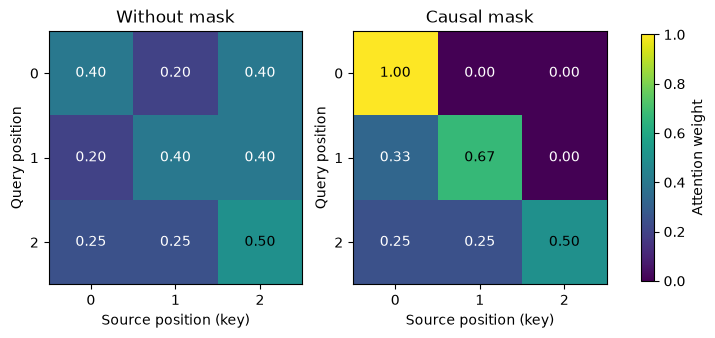

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, (A, _)) in zip(axes, results.items()):
    im = ax.imshow(A.numpy(), vmin=0, vmax=1, cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("Source position (key)")
    ax.set_ylabel("Query position")
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    for i in range(3):
        for j in range(3):
            v = A[i, j].item()
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black")
fig.colorbar(im, ax=axes, shrink=0.8, label="Attention weight")
plt.show()

In [ ]:
changed_E = E.clone()
changed_E[2] = torch.tensor([4.0, 4.0])

for name, causal in [("Without mask", False), ("Causal mask", True)]:
    _, upd_orig = attention(E, causal)
    _, upd_new  = attention(changed_E, causal)
    max_change = (upd_new[:2] - upd_orig[:2]).abs().max().item()
    print(f"{name:13s} | largest absolute change in first two updated rows: {max_change:.6f}")

Without mask  | largest absolute change in first two updated rows: 2.844011
Causal mask   | largest absolute change in first two updated rows: 0.000000


With the causal mask, row i's scores for columns j > i are set to negative infinity, so softmax gives them exactly zero weight and the first two rows of A only use tokens 0 and 1. Rows 0 and 1 of updated depend only on E[0], E[1] and the weights, so changing E[2] leaves them unchanged (change of 0), while without the mask the change is 2.844011. This matters for a next-token predictor because the output at position i is used to predict token i+1, and that output must not depend on token i+1 or later. The mask enforces this inside the model, so the predictor cannot copy the answer from future inputs during training.

In [4]:
train_sub, val_sub, _ = random_split(
    full_train, [6000, 1000, len(full_train) - 7000],
    generator=torch.Generator().manual_seed(SEED)   # identical split to Q1
)

def to_tensors(base, indices=None):
    x, y = base.data, base.targets
    if indices is not None:
        x, y = x[indices], y[indices]
    return (x.float() / 255.0).to(device), y.clone().to(device)   # x: (N, 28, 28)

Xtr, Ytr = to_tensors(full_train, train_sub.indices)
Xva, Yva = to_tensors(full_train, val_sub.indices)
Xte, Yte = to_tensors(test_ds)
print(Xtr.shape, Xva.shape, Xte.shape)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

torch.Size([6000, 28, 28]) torch.Size([1000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
def patchify(x):
    """(B, 28, 28) -> (B, 49, 16). Patches go left to right, then top to bottom;
    each patch is flattened in row-major order."""
    B = x.shape[0]
    x = x.reshape(B, 7, 4, 7, 4)          # (B, patch_row, row_in_patch, patch_col, col_in_patch)
    x = x.permute(0, 1, 3, 2, 4)          # (B, patch_row, patch_col, row_in_patch, col_in_patch)
    return x.reshape(B, 49, 16)

def unpatchify(p):
    """(B, 49, 16) -> (B, 28, 28). Exact inverse of patchify."""
    B = p.shape[0]
    p = p.reshape(B, 7, 7, 4, 4).permute(0, 1, 3, 2, 4)
    return p.reshape(B, 28, 28)

# sanity checks
assert torch.equal(unpatchify(patchify(Xte[:50])), Xte[:50])
assert torch.equal(patchify(Xte[:1])[0, 1], Xte[0, 0:4, 4:8].reshape(-1))   # patch 1 = top row, 2nd block
assert torch.equal(patchify(Xte[:1])[0, 7], Xte[0, 4:8, 0:4].reshape(-1))   # patch 7 = 2nd row, 1st block
print("patch helpers OK")

patch helpers OK


In [5]:
class PatchTransformer(nn.Module):
    def __init__(self, use_pos):
        super().__init__()
        self.use_pos = use_pos
        self.patch_proj = nn.Linear(16, 32)
        self.cls_token = nn.Parameter(torch.randn(1, 1, 32) * 0.02)
        self.pos_table = nn.Parameter(torch.randn(50, 32) * 0.02)   # exists in both variants
        self.norm1 = nn.LayerNorm(32)
        self.attention = nn.MultiheadAttention(
            embed_dim=32, num_heads=2, dropout=0.0, batch_first=True
        )
        self.norm2 = nn.LayerNorm(32)
        self.mlp = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32))
        self.final_norm = nn.LayerNorm(32)
        self.classifier = nn.Linear(32, 10)

    def forward(self, images):
        x = self.patch_proj(patchify(images))                   # (B, 49, 32)
        cls = self.cls_token.expand(x.shape[0], -1, -1)         # (B, 1, 32)
        X = torch.cat([cls, x], dim=1)                          # (B, 50, 32), row 0 is CLS
        if self.use_pos:
            X = X + self.pos_table                              # position stays with the slot
        normalized = self.norm1(X)
        message, _ = self.attention(normalized, normalized, normalized)   # no mask
        U = X + message
        Z = U + self.mlp(self.norm2(U))
        return self.classifier(self.final_norm(Z[:, 0, :]))

# One set of initial weights shared by both variants
set_seed(SEED)
init_state = copy.deepcopy(PatchTransformer(use_pos=True).state_dict())
print("parameters:", sum(p.numel() for p in PatchTransformer(True).parameters()))

parameters: 11114


In [6]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, X, Y, bs=1000):
    model.eval()
    tot_loss, correct = 0.0, 0
    for i in range(0, len(X), bs):
        x, y = X[i:i+bs], Y[i:i+bs]
        logits = model(x)
        tot_loss += criterion(logits, y).item() * y.size(0)   # batch mean -> batch total
        correct  += (logits.argmax(-1) == y).sum().item()
    return tot_loss / len(X), correct / len(X)

def train_variant(use_pos, epochs=10, batch=128):
    model = PatchTransformer(use_pos).to(device)
    model.load_state_dict(init_state)
    opt = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    g = torch.Generator().manual_seed(SEED)          # same shuffle order for both variants

    best_val, best_epoch, best_state = float("inf"), None, None
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(len(Xtr), generator=g).to(device)
        for i in range(0, len(Xtr), batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            criterion(model(Xtr[idx]), Ytr[idx]).backward()
            opt.step()

        val_loss, val_acc = evaluate(model, Xva, Yva)
        print(f"epoch {ep:2d} | val CE {val_loss:.4f} | val acc {val_acc:.4f}")
        if val_loss < best_val:                      # strict '<' keeps the earlier epoch on ties
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)                # restore before testing
    return model, best_epoch

In [7]:
rng = np.random.default_rng(44)
orders = np.stack([rng.permutation(49) for _ in range(len(Xte))])   # official test order
orders_t = torch.from_numpy(orders).long().to(device)               # (10000, 49)

patches = patchify(Xte)                                             # (10000, 49, 16)
# destination slot k receives original patch orders[i, k]; pixels inside patches are untouched
shuffled_patches = torch.gather(patches, 1, orders_t.unsqueeze(-1).expand(-1, -1, 16))
Xte_shuf = unpatchify(shuffled_patches)                             # same images used for both models

assert torch.equal(torch.sort(patches[0], dim=0).values,
                   torch.sort(shuffled_patches[0], dim=0).values)   # same patches, new order
print(Xte_shuf.shape)

torch.Size([10000, 28, 28])


In [8]:
rows = {}
for name, use_pos in [("With positions", True), ("No positions", False)]:
    print(f"\n=== {name} ===")
    model, best_ep = train_variant(use_pos)
    _, acc_orig = evaluate(model, Xte, Yte)
    _, acc_shuf = evaluate(model, Xte_shuf, Yte)     # original labels, no retraining
    rows[name] = (best_ep, acc_orig, acc_shuf)

print("\n{:<16}{:>16}{:>16}{:>18}{:>10}".format(
    "Model", "Selected epoch", "Test acc", "Shuffled acc", "Drop"))
for k, (ep, a, s) in rows.items():
    print("{:<16}{:>16d}{:>16.4f}{:>18.4f}{:>10.4f}".format(k, ep, a, s, a - s))


=== With positions ===
epoch  1 | val CE 1.4520 | val acc 0.4380
epoch  2 | val CE 1.1183 | val acc 0.5820
epoch  3 | val CE 0.9198 | val acc 0.6250
epoch  4 | val CE 0.8222 | val acc 0.6660
epoch  5 | val CE 0.8157 | val acc 0.6780
epoch  6 | val CE 0.7009 | val acc 0.7390
epoch  7 | val CE 0.7013 | val acc 0.7440
epoch  8 | val CE 0.6772 | val acc 0.7500
epoch  9 | val CE 0.6416 | val acc 0.7400
epoch 10 | val CE 0.6331 | val acc 0.7660

=== No positions ===
epoch  1 | val CE 1.6493 | val acc 0.3700
epoch  2 | val CE 1.4313 | val acc 0.4520
epoch  3 | val CE 1.2781 | val acc 0.4980
epoch  4 | val CE 1.2286 | val acc 0.5100
epoch  5 | val CE 1.1631 | val acc 0.5470
epoch  6 | val CE 1.1234 | val acc 0.5940
epoch  7 | val CE 1.1239 | val acc 0.5680
epoch  8 | val CE 1.0712 | val acc 0.6020
epoch  9 | val CE 1.0490 | val acc 0.6020
epoch 10 | val CE 1.0682 | val acc 0.5770

Model             Selected epoch        Test acc      Shuffled acc      Drop
With positions                10    

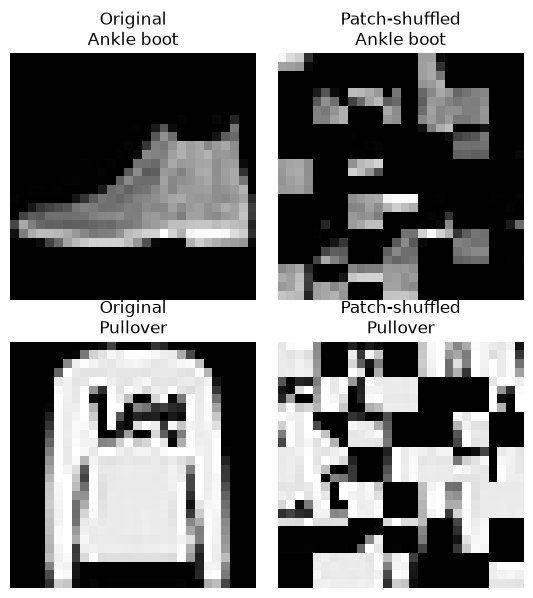

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(5.5, 6))
for r in range(2):
    label = class_names[Yte[r].item()]
    axes[r, 0].imshow(Xte[r].cpu(), cmap="gray")
    axes[r, 0].set_title(f"Original\n{label}")
    axes[r, 1].imshow(Xte_shuf[r].cpu(), cmap="gray")
    axes[r, 1].set_title(f"Patch-shuffled\n{label}")
    for c in range(2):
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()